# 03 - Risk Scoring and Forecasting

## Purpose
Fit the training-only risk scoring pipeline, train lightweight forecasting models, save all model artifacts, and write per-model plus best-model prediction reports.

## Inputs
- `data/processed/processed_data.csv`

## Outputs
- Model artifacts in `artifacts/`
- Metrics and prediction reports in `reports/`

## Notes
The learned score is an environmental anomaly and directional risk proxy, not a calibrated flood or drought probability.


## 1. Configure Modeling Paths
Defines the project root, config path, and execution switch for the prototype modeling run.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.yaml"
RUN_RISK_MODEL = True

## 2. Preview Processed Dataset and Temporal Split
Loads `processed_data.csv` and previews the intended chronological split before fitting any model.

In [2]:
import pandas as pd
from src.validation import load_project_config
from src.risk_scoring import build_forecasting_table, split_forecasting_rows

config = load_project_config(CONFIG_PATH)
processed_path = PROJECT_ROOT / config["paths"]["processed_data_csv"]
processed = pd.read_csv(processed_path)
forecasting_preview = build_forecasting_table(processed.assign(
    anomaly_magnitude=0.0,
    signed_risk_score=0.0,
    risk_direction="neutral",
    risk_severity="low",
))
splits = split_forecasting_rows(forecasting_preview, config)
print("processed", processed.shape)
print({name: int(mask.sum()) for name, mask in splits.items()})
processed.head()

processed (3234, 177)
{'train': 2548, 'test': 588, 'holdout': 49}


C:\Users\Aki\AppData\Local\Temp\ipykernel_36600\68467630.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  forecasting_preview = build_forecasting_table(processed.assign(


,sample_id,grid_row,grid_col,latitude,longitude,month,ndvi_mean,evi_mean,ndmi_mean,ndwi_mean,...,water_probability_mean_difference_3m,flooded_vegetation_probability_mean_lag_1,flooded_vegetation_probability_mean_lag_3,flooded_vegetation_probability_mean_lag_6,flooded_vegetation_probability_mean_lag_12,flooded_vegetation_probability_mean_rolling_mean_3,flooded_vegetation_probability_mean_rolling_mean_6,flooded_vegetation_probability_mean_rolling_mean_12,flooded_vegetation_probability_mean_difference_1m,flooded_vegetation_probability_mean_difference_3m
0,sagil_1,0,0,2.341985,102.629998,2021-01-01,0.559763,0.445020,0.106943,-0.527780,...,NaN,NaN,NaN,NaN,NaN,0.034129,0.034129,0.034129,NaN,NaN
1,sagil_1,0,0,2.341985,102.629998,2021-02-01,0.455169,0.350538,0.100939,-0.444946,...,NaN,0.034129,NaN,NaN,NaN,0.034129,0.034129,0.034129,NaN,NaN
2,sagil_1,0,0,2.341985,102.629998,2021-03-01,0.419253,0.367311,0.051128,-0.422619,...,NaN,NaN,NaN,NaN,NaN,0.033250,0.033250,0.033250,NaN,NaN
3,sagil_1,0,0,2.341985,102.629998,2021-04-01,0.669163,0.591764,0.192576,-0.590714,...,-0.00213,0.032371,0.034129,NaN,NaN,0.031581,0.032431,0.032431,-0.001579,-0.003337
4,sagil_1,0,0,2.341985,102.629998,2021-05-01,0.719184,0.647537,0.246818,-0.618140,...,NaN,0.030792,NaN,NaN,NaN,0.037135,0.036383,0.036383,0.017449,NaN


## 3. Run Prototype Risk Scoring and Forecasting
Fits reconstruction models, trains persistence/Ridge/Random Forest, saves all artifacts, and writes best-model plus per-model reports.


In [3]:
from src.risk_scoring import run_risk_scoring_and_forecasting

if RUN_RISK_MODEL:
    result = run_risk_scoring_and_forecasting(CONFIG_PATH)
    print(result)
else:
    print("RUN_RISK_MODEL is False.")

{'scored_rows': 3234, 'forecasting_rows': 3234, 'best_model': 'persistence', 'metrics': {'persistence': {'mae': 0.23843842520239966, 'median_ae': 0.210890990101344, 'rmse': 0.33028221703678556, 'r2': -0.5284839754905886, 'bias': -0.01409045662096531, 'direction_accuracy': 0.6870748299319728}, 'ridge': {'mae': 0.2809519936209434, 'median_ae': 0.2327474797239705, 'rmse': 0.3609692081245486, 'r2': -0.8257059086610845, 'bias': 0.06483973773694572, 'direction_accuracy': 0.6071428571428571}, 'random_forest': {'mae': 0.24693350876393017, 'median_ae': 0.180940675308926, 'rmse': 0.3456478627600302, 'r2': -0.6740108147619224, 'bias': 0.16410206710559438, 'direction_accuracy': 0.6632653061224489}}}


## 4. Evaluation Metrics
Loads saved metrics and displays model comparison across MAE, median absolute error, RMSE, R2, prediction bias, and flood/drought sign accuracy. Lower MAE/RMSE is better; higher R2 and direction accuracy are better.

In [4]:
import json
import pandas as pd
from src.risk_scoring import metrics_frame

reports_dir = PROJECT_ROOT / config["paths"]["reports_dir"]
metrics_path = reports_dir / "metrics.json"

if metrics_path.exists():
    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    metric_table = metrics_frame(metrics)
    display(metric_table)
else:
    metric_table = pd.DataFrame()
    print("No metrics report found yet. Run section 3 first.")

,model,mae,median_ae,rmse,r2,bias,direction_accuracy
0,persistence,0.238438,0.210891,0.330282,-0.528484,-0.014090,0.687075
2,random_forest,0.246934,0.180941,0.345648,-0.674011,0.164102,0.663265
1,ridge,0.280952,0.232747,0.360969,-0.825706,0.064840,0.607143


## 5. Prediction Error Diagnostics
Inspects test-period Random Forest predictions and summarizes residual error by target month and grid cell.

In [5]:
test_predictions_path = reports_dir / "test_predictions.csv"

if test_predictions_path.exists():
    test_predictions = pd.read_csv(test_predictions_path)
    test_predictions["error"] = test_predictions["predicted_proxy_score"] - test_predictions["actual_proxy_score"]
    test_predictions["absolute_error"] = test_predictions["error"].abs()
    display(test_predictions.head())
    monthly_error = (
        test_predictions.groupby("target_month", as_index=False)["absolute_error"]
        .mean()
        .rename(columns={"absolute_error": "mean_absolute_error"})
    )
    cell_error = (
        test_predictions.groupby("sample_id", as_index=False)["absolute_error"]
        .mean()
        .rename(columns={"absolute_error": "mean_absolute_error"})
        .sort_values("mean_absolute_error", ascending=False)
    )
    display(monthly_error)
    display(cell_error.head(10))
else:
    print("No test prediction report found yet.")

,sample_id,month,target_month,actual_proxy_score,risk_direction,risk_severity,predicted_proxy_score,model,split,error,absolute_error
0,sagil_1,2025-05-01,2025-06-01,-0.206594,drought,low,-0.052298,persistence,test,0.154295,0.154295
1,sagil_1,2025-06-01,2025-07-01,-0.324576,drought,moderate,-0.206594,persistence,test,0.117982,0.117982
2,sagil_1,2025-07-01,2025-08-01,-0.091162,drought,high,-0.324576,persistence,test,-0.233414,0.233414
3,sagil_1,2025-08-01,2025-09-01,-0.069916,drought,low,-0.091162,persistence,test,-0.021245,0.021245
4,sagil_1,2025-09-01,2025-10-01,-0.156710,drought,low,-0.069916,persistence,test,0.086794,0.086794


,target_month,mean_absolute_error
0,2025-06-01,0.164294
1,2025-07-01,0.220119
2,2025-08-01,0.259526
3,2025-09-01,0.187893
4,2025-10-01,0.177032
5,2025-11-01,0.294929
6,2025-12-01,0.183883
7,2026-01-01,0.407129
8,2026-02-01,0.181452
9,2026-03-01,0.121472


,sample_id,mean_absolute_error
28,sagil_35,0.510624
27,sagil_34,0.495622
36,sagil_42,0.391954
6,sagil_15,0.377383
24,sagil_31,0.354881
31,sagil_38,0.344641
1,sagil_10,0.334671
22,sagil_3,0.305255
15,sagil_23,0.282942
26,sagil_33,0.272369


## 6. Model Result Visualizations
Plots the model comparison metrics, best-model test predictions, residuals, and holdout predictions. Live coordinate inference is handled separately in notebook 06.


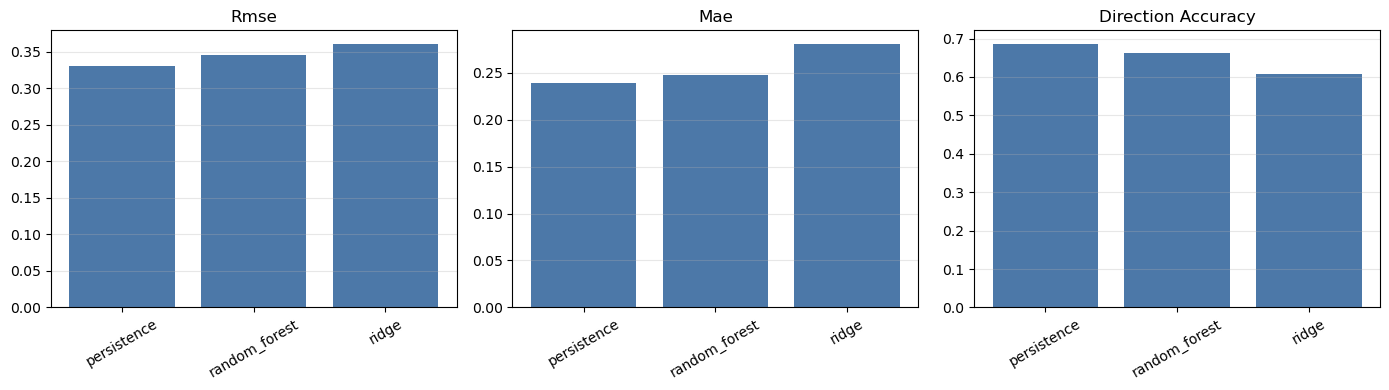

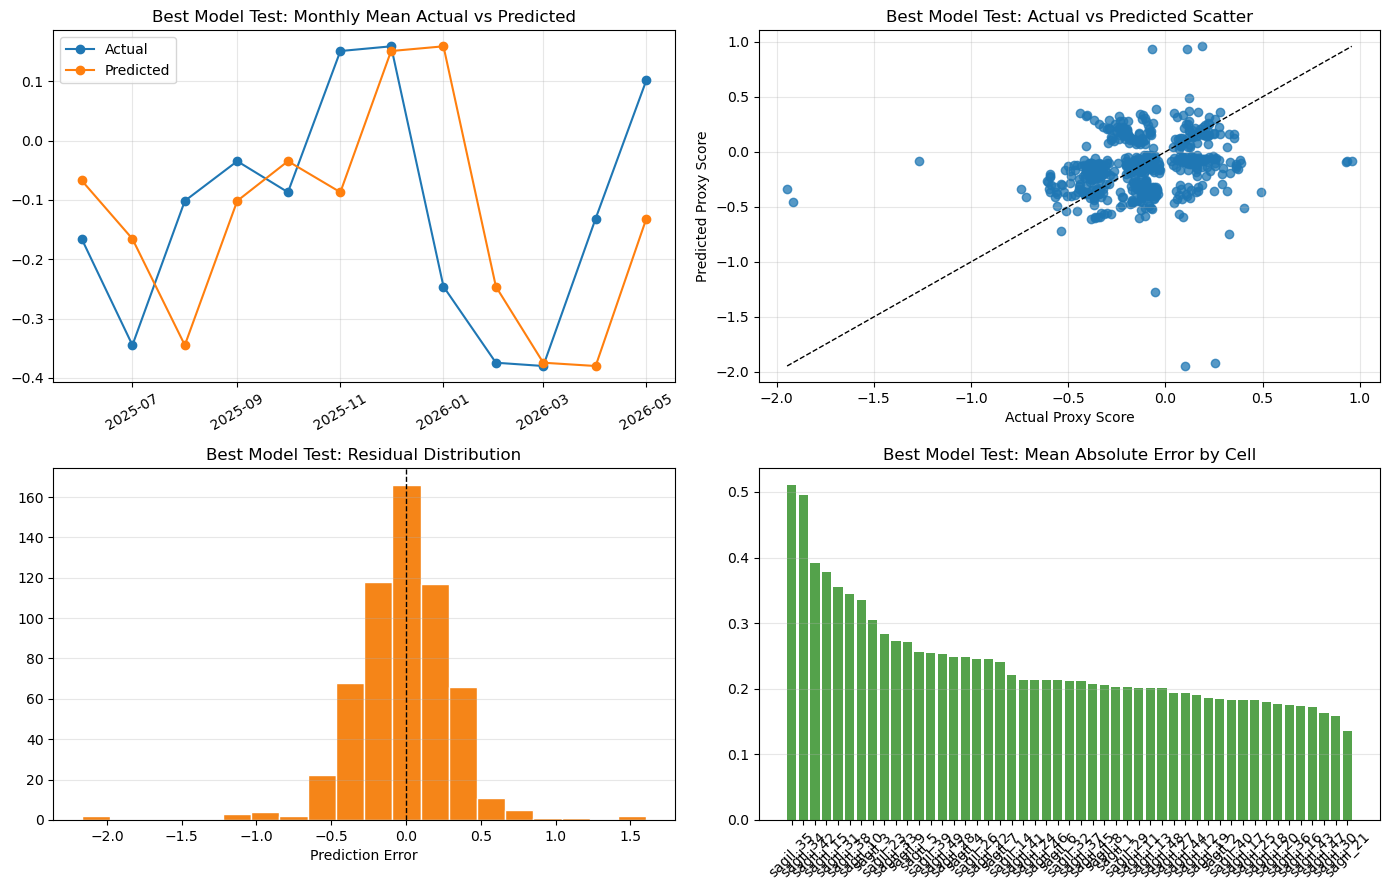

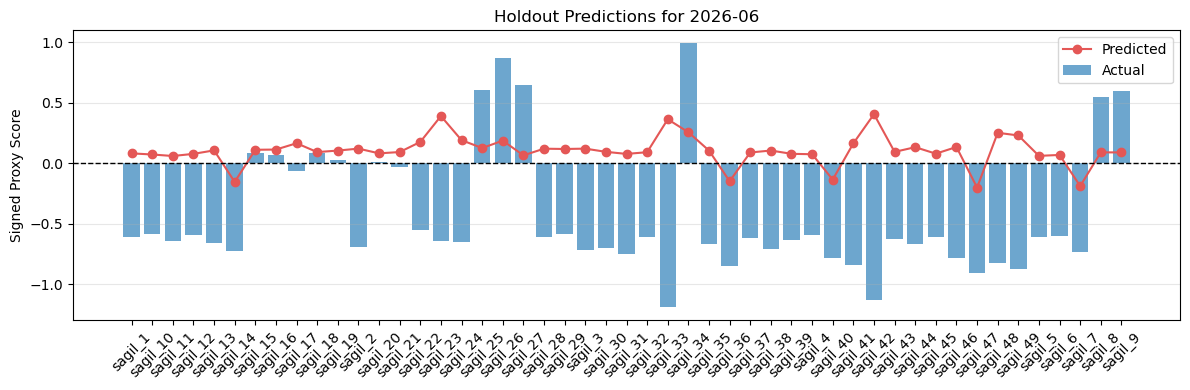

In [6]:
import matplotlib.pyplot as plt


def plot_metric_bars(metric_table):
    if metric_table.empty:
        print("No metric table available for plotting.")
        return
    metrics_to_plot = ["rmse", "mae", "direction_accuracy"]
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4))
    for axis, metric in zip(axes, metrics_to_plot):
        sorted_table = metric_table.sort_values(metric, ascending=(metric != "direction_accuracy"))
        axis.bar(sorted_table["model"], sorted_table[metric], color="#4C78A8")
        axis.set_title(metric.replace("_", " ").title())
        axis.tick_params(axis="x", rotation=30)
        axis.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_prediction_diagnostics(predictions, title_prefix):
    if predictions.empty:
        print(f"No predictions available for {title_prefix}.")
        return
    working = predictions.copy()
    working["target_month"] = pd.to_datetime(working["target_month"])
    working["error"] = working["predicted_proxy_score"] - working["actual_proxy_score"]
    working = working.sort_values(["target_month", "sample_id"])

    monthly = working.groupby("target_month", as_index=False)[["actual_proxy_score", "predicted_proxy_score"]].mean()
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(monthly["target_month"], monthly["actual_proxy_score"], marker="o", label="Actual")
    axes[0, 0].plot(monthly["target_month"], monthly["predicted_proxy_score"], marker="o", label="Predicted")
    axes[0, 0].set_title(f"{title_prefix}: Monthly Mean Actual vs Predicted")
    axes[0, 0].tick_params(axis="x", rotation=30)
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].scatter(working["actual_proxy_score"], working["predicted_proxy_score"], alpha=0.75)
    lower = min(working["actual_proxy_score"].min(), working["predicted_proxy_score"].min())
    upper = max(working["actual_proxy_score"].max(), working["predicted_proxy_score"].max())
    axes[0, 1].plot([lower, upper], [lower, upper], linestyle="--", color="black", linewidth=1)
    axes[0, 1].set_title(f"{title_prefix}: Actual vs Predicted Scatter")
    axes[0, 1].set_xlabel("Actual Proxy Score")
    axes[0, 1].set_ylabel("Predicted Proxy Score")
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].hist(working["error"], bins=20, color="#F58518", edgecolor="white")
    axes[1, 0].axvline(0, linestyle="--", color="black", linewidth=1)
    axes[1, 0].set_title(f"{title_prefix}: Residual Distribution")
    axes[1, 0].set_xlabel("Prediction Error")
    axes[1, 0].grid(axis="y", alpha=0.3)

    cell_error = working.groupby("sample_id")["error"].apply(lambda values: values.abs().mean()).sort_values(ascending=False)
    axes[1, 1].bar(cell_error.index, cell_error.values, color="#54A24B")
    axes[1, 1].set_title(f"{title_prefix}: Mean Absolute Error by Cell")
    axes[1, 1].tick_params(axis="x", rotation=45)
    axes[1, 1].grid(axis="y", alpha=0.3)

    fig.tight_layout()
    plt.show()


def plot_holdout_predictions(holdout_path):
    if not holdout_path.exists():
        print("No holdout prediction report found for plotting.")
        return
    holdout = pd.read_csv(holdout_path)
    if holdout.empty:
        print("Holdout prediction report is empty.")
        return
    x_labels = holdout["sample_id"].astype(str)
    fig, axis = plt.subplots(figsize=(12, 4))
    axis.bar(x_labels, holdout["actual_proxy_score"], alpha=0.65, label="Actual")
    axis.plot(x_labels, holdout["predicted_proxy_score"], marker="o", color="#E45756", label="Predicted")
    axis.axhline(0, linestyle="--", color="black", linewidth=1)
    axis.set_title("Holdout Predictions for 2026-06")
    axis.set_ylabel("Signed Proxy Score")
    axis.tick_params(axis="x", rotation=45)
    axis.legend()
    axis.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()



plot_metric_bars(metric_table)
if test_predictions_path.exists():
    plot_prediction_diagnostics(pd.read_csv(test_predictions_path), "Best Model Test")
plot_holdout_predictions(reports_dir / "holdout_predictions.csv")
